# 3D HEALPix Sphere Visualization

This notebook creates 3D visualizations of HEALPix spheres showing:
- Cell boundaries as line segments
- Unique colors per pixel
- Multiple resolutions (nside) in a row comparison

## Setup and Imports

In [31]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection, Line3DCollection
import matplotlib.cm as cm

# Matplotlib styling
plt.rc("font", family="serif")
plt.rc("mathtext", **{"default": "regular"})
plt.style.use("seaborn-v0_8-paper")
plt.rc("xtick", **{"direction": "in"})
plt.rc("ytick", **{"direction": "in"})

## 3D HEALPix Visualization Function

This function plots a HEALPix sphere in 3D with:
- Polygon faces colored uniquely per pixel
- Line segments showing cell boundaries

In [32]:
def plot_healpix_sphere_3d(
    nside,
    map_data=None,
    cmap="hsv",
    show_boundaries=True,
    ax=None,
    boundary_color="black",
    boundary_width=0.5,
    alpha=0.9,
    title=None,
):
    """
    Plot HEALPix sphere in 3D with cell boundaries and unique colors per cell.

    Parameters:
        nside: int - HEALPix resolution parameter (power of 2)
        map_data: array - Optional data values per pixel for coloring (default: pixel index)
        cmap: str - Colormap name for cell colors
        show_boundaries: bool - Whether to show cell boundary lines
        ax: Axes3D - Existing 3D axes (optional)
        boundary_color: str - Color for boundary lines
        boundary_width: float - Line width for boundaries
        alpha: float - Transparency of cell faces
        title: str - Title for the plot

    Returns:
        ax: Axes3D - The matplotlib 3D axes object
    """
    npix = hp.nside2npix(nside)

    # Create figure and 3D axes if not provided
    if ax is None:
        fig = plt.figure(figsize=(10, 10))
        ax = fig.add_subplot(111, projection="3d")

    # Get colormap
    colormap = cm.get_cmap(cmap)

    # Use pixel index for unique colors if no data provided
    if map_data is None:
        map_data = np.arange(npix)

    # Normalize data for colormap
    norm = plt.Normalize(map_data.min(), map_data.max())

    polygons = []
    colors = []
    boundary_lines = []

    # Use more steps for low nside to make pixels look more spherical
    # step parameter adds intermediate points along pixel edges
    if nside <= 2:
        step = 32  # Many points for very low resolution (smoother curves)
    elif nside <= 4:
        step = 16
    elif nside <= 8:
        step = 8
    elif nside <= 16:
        step = 4
    else:
        step = 1  # High resolution doesn't need extra smoothing

    for ipix in range(npix):
        # Get boundary vertices
        # hp.boundaries returns shape (3, 4*step) - x, y, z coordinates
        # Higher step = more vertices along each edge = smoother appearance
        boundaries = hp.boundaries(nside, ipix, step=step, nest=False)

        # Transpose to get list of (x, y, z) vertices
        vertices = boundaries.T  # Shape: (4*step, 3)

        # Get pixel center for triangulation
        theta, phi = hp.pix2ang(nside, ipix, nest=False)
        center = np.array(
            [np.sin(theta) * np.cos(phi), np.sin(theta) * np.sin(phi), np.cos(theta)]
        )

        # Create triangular fan from center to boundary vertices
        # This makes the surface follow the sphere better
        color = colormap(norm(map_data[ipix]))
        for j in range(len(vertices)):
            v1 = vertices[j]
            v2 = vertices[(j + 1) % len(vertices)]
            # Create triangle: center -> v1 -> v2
            triangle = np.array([center, v1, v2])
            polygons.append(triangle)
            colors.append(color)

        if show_boundaries:
            # Create line segments for cell edges (only along pixel boundaries, not internal triangles)
            boundary_step = step  # Use same step for boundary lines
            boundary_verts = hp.boundaries(
                nside, ipix, step=boundary_step, nest=False
            ).T
            for j in range(len(boundary_verts)):
                line = [
                    boundary_verts[j],
                    boundary_verts[(j + 1) % len(boundary_verts)],
                ]
                boundary_lines.append(line)

    # Add all cell polygons as a collection
    poly_collection = Poly3DCollection(polygons, alpha=alpha)
    poly_collection.set_facecolors(colors)
    # Don't draw edges on triangles (internal subdivisions)
    poly_collection.set_edgecolors("none")
    ax.add_collection3d(poly_collection)

    # Draw pixel boundary lines separately
    if show_boundaries and boundary_lines:
        line_collection = Line3DCollection(
            boundary_lines, colors=boundary_color, linewidths=boundary_width
        )
        ax.add_collection3d(line_collection)

    # Set axis properties for unit sphere
    ax.set_xlim([-1.1, 1.1])
    ax.set_ylim([-1.1, 1.1])
    ax.set_zlim([-1.1, 1.1])
    ax.set_box_aspect([1, 1, 1])

    # Remove grids, axis labels, and ticks for clean sphere visualization
    ax.set_axis_off()

    return ax

## Single Sphere Example

Test the visualization with a single nside value

/tmp/ipykernel_3049957/2895278254.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap(cmap)


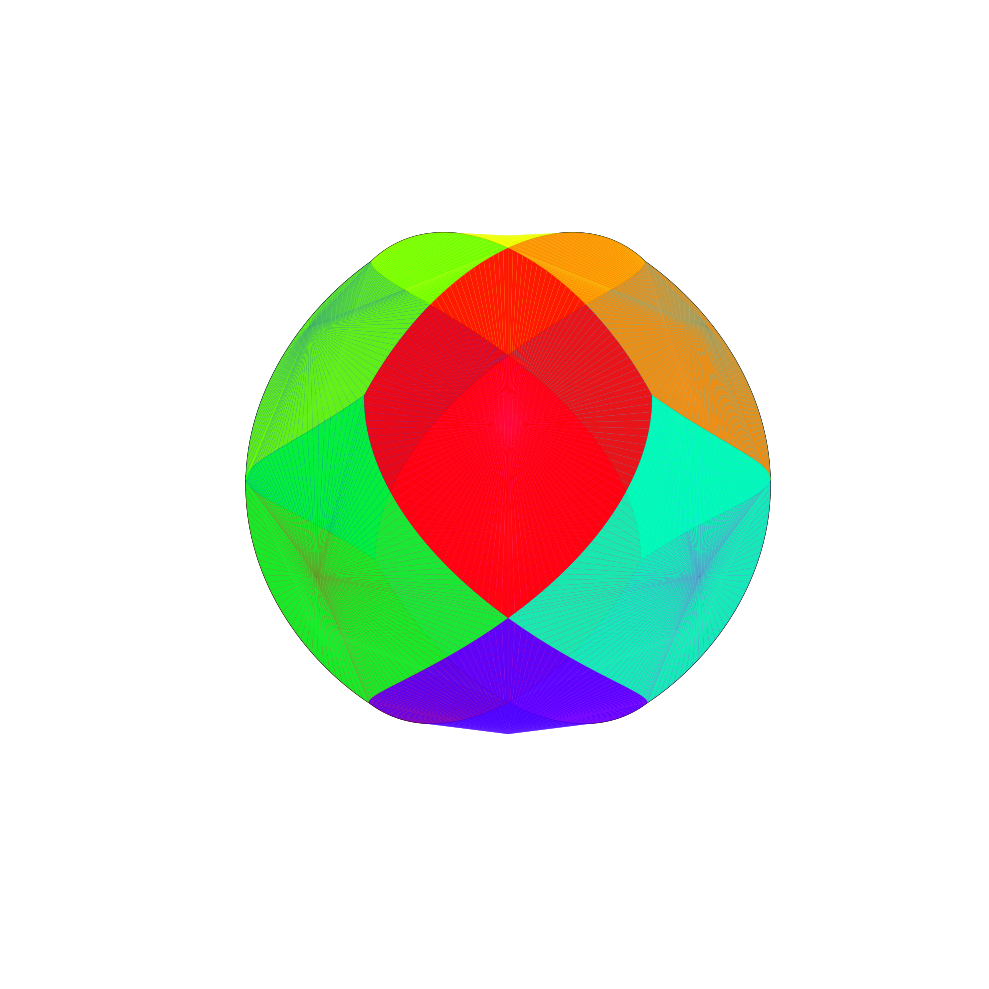

In [37]:
# Test with nside=4 (192 pixels)
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection="3d")
plot_healpix_sphere_3d(nside=1, ax=ax, title="HEALPix Sphere (nside=4)")
ax.view_init(elev=30, azim=45)
plt.tight_layout()
plt.show()

## Multi-Resolution Comparison

Display HEALPix spheres at different resolutions in a row.

**Note:** Original request was for nside=256, 64, 16, 1. However:
- nside=256 has 786,432 pixels (too many for efficient 3D rendering)
- nside=64 has 49,152 pixels (still quite slow)
- Using nside=32, 16, 4, 1 for better performance while still showing the concept

If you need higher resolution, consider using the 2D Mollweide projection from healpy instead.

/tmp/ipykernel_3049957/2895278254.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap(cmap)


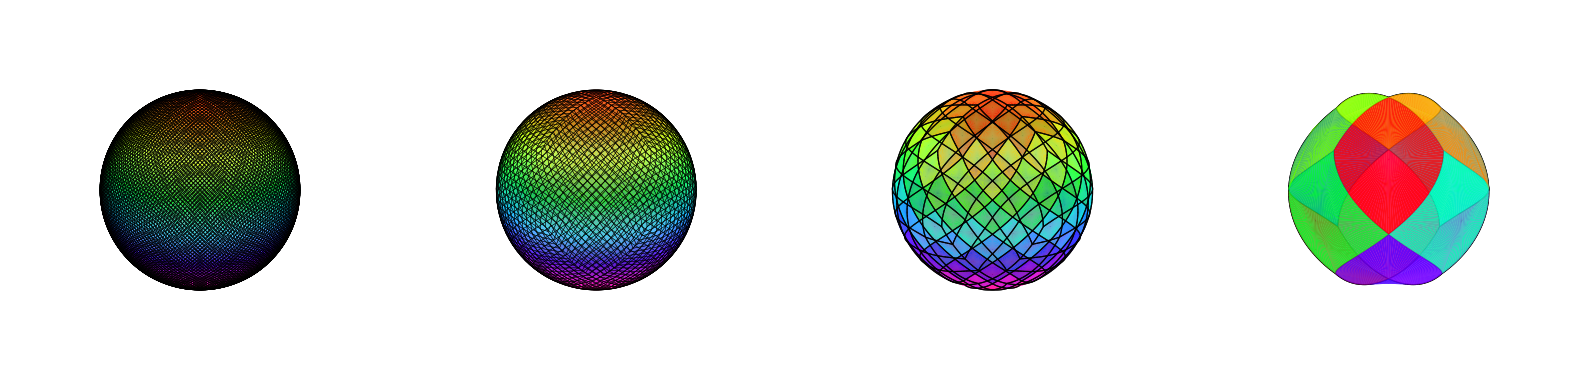

In [34]:
# Multi-resolution comparison: nside = 32, 16, 4, 1
# Note: Higher nside values (64, 256) would be too slow for 3D rendering
nsides = [32, 16, 4, 1]

# Use square subplots (16x4 = 4:1 aspect for 4 square subplots)
fig = plt.figure(figsize=(16, 4))

for i, nside in enumerate(nsides):
    ax = fig.add_subplot(1, 4, i + 1, projection="3d")
    npix = hp.nside2npix(nside)
    plot_healpix_sphere_3d(
        nside=nside,
        ax=ax,
        cmap="hsv",
        boundary_width=0.8 if nside <= 4 else 0.3,
        alpha=0.85,
    )
    ax.view_init(elev=25, azim=45)
    # Ensure equal aspect ratio for spherical appearance
    ax.set_box_aspect([1, 1, 1])

plt.tight_layout()
plt.show()

## Higher Resolution Version (Slower)

Attempting the originally requested nside values. **Warning:** This may take significant time to render.

Rendering nside=64 (49152 pixels)...


/tmp/ipykernel_3049957/2895278254.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap(cmap)


Rendering nside=16 (3072 pixels)...
Rendering nside=4 (192 pixels)...
Rendering nside=4 (192 pixels)...
Rendering nside=1 (12 pixels)...
Rendering nside=1 (12 pixels)...


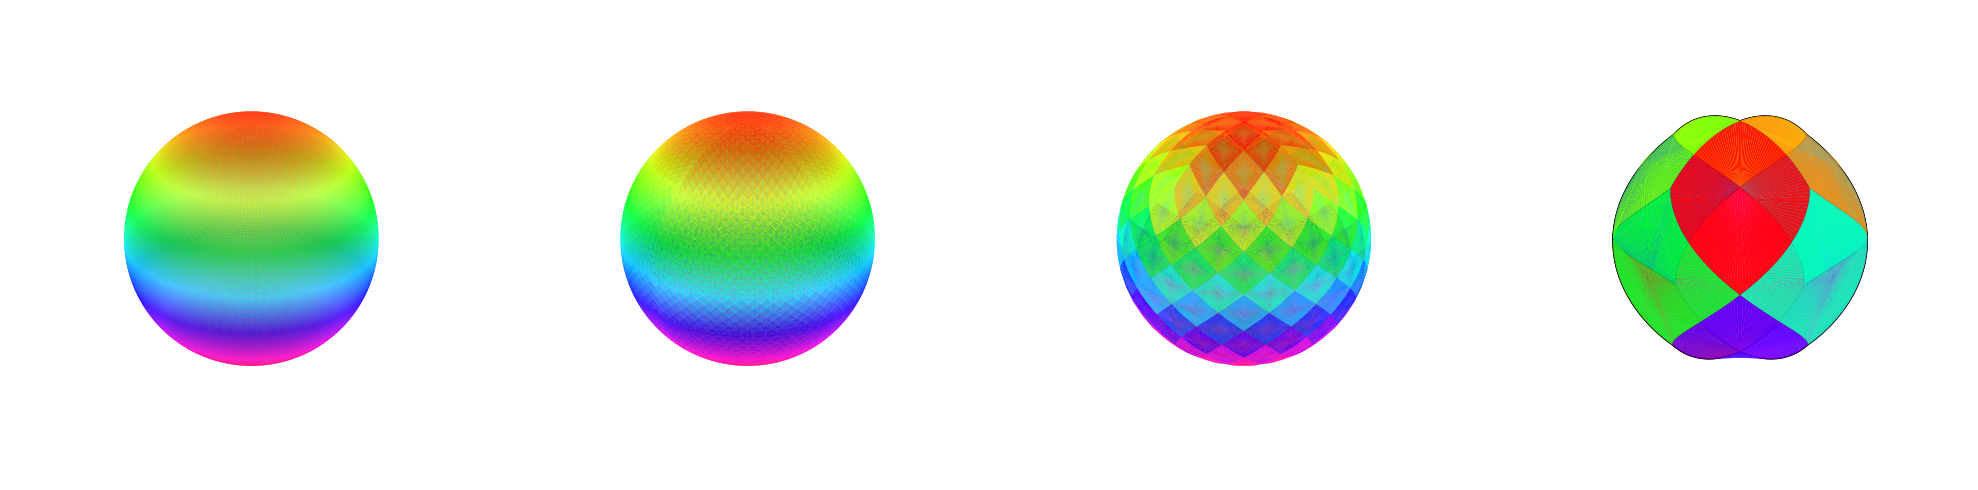

Done!


In [35]:
# Original requested nside values: 256, 64, 16, 1
# WARNING: nside=256 has 786,432 pixels - this will be VERY slow
# Uncomment and run if you want to try (may crash or hang)

nsides_high = [64, 16, 4, 1]  # Using 64 as max for reasonable performance

fig = plt.figure(figsize=(20, 5))

for i, nside in enumerate(nsides_high):
    print(f"Rendering nside={nside} ({hp.nside2npix(nside)} pixels)...")
    ax = fig.add_subplot(1, 4, i + 1, projection="3d")
    npix = hp.nside2npix(nside)
    plot_healpix_sphere_3d(
        nside=nside,
        ax=ax,
        cmap="hsv",
        boundary_width=0.2 if nside >= 64 else (0.5 if nside >= 16 else 1.0),
        alpha=0.9,
        show_boundaries=(nside <= 1),  # Hide boundaries for very high res
    )
    ax.view_init(elev=25, azim=45)

plt.tight_layout()
plt.show()
print("Done!")

## Different View Angles

Show the same sphere from multiple viewing angles to better visualize the HEALPix structure

/tmp/ipykernel_3049957/2895278254.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap(cmap)


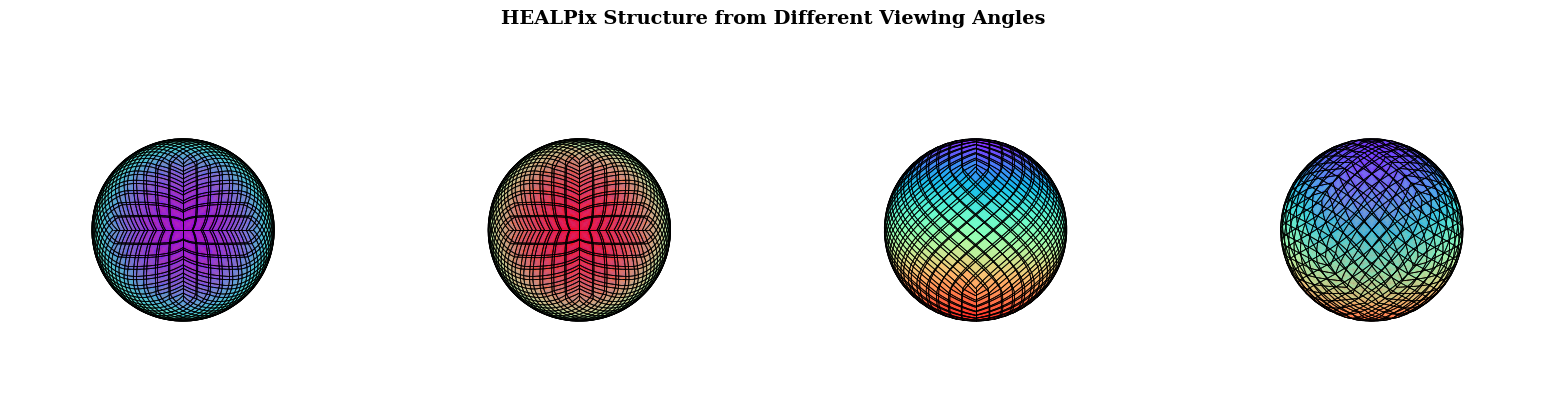

In [36]:
# Show sphere from different angles
nside = 8
views = [
    (90, 0, "Top View (North Pole)"),
    (-90, 0, "Bottom View (South Pole)"),
    (0, 0, "Side View"),
    (30, 45, "Oblique View"),
]

fig = plt.figure(figsize=(16, 4))

for i, (elev, azim, view_name) in enumerate(views):
    ax = fig.add_subplot(1, 4, i + 1, projection="3d")
    plot_healpix_sphere_3d(
        nside=nside,
        ax=ax,
        title=f"{view_name}\nnside={nside}",
        cmap="rainbow",
        boundary_width=0.6,
    )
    ax.view_init(elev=elev, azim=azim)

plt.suptitle(
    "HEALPix Structure from Different Viewing Angles",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()